# FEP background raw view

Use this notebook to preview the tubing/background .xy file without baseline correction or normalization.
The data is not modified; this is just a raw plot for inspection.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Path to the tubing/background .xy file
data_folder = r"E:/I11 Beamtime July 25 - LHIST/Powder_patterns/"
file_name = "FEP_background_subtraction (2).xy"
file_path = os.path.join(data_folder, file_name)

# Simple .xy reader (2 columns, skips non-numeric lines)
def read_xy(filepath):
    x, y = [], []
    with open(filepath, "r") as handle:
        for line in handle:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
            except ValueError:
                continue
    return np.array(x), np.array(y)

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

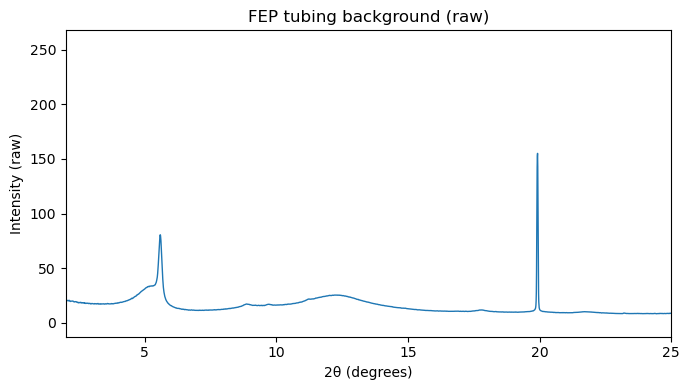

Loaded 4000 points from FEP_background_subtraction (2).xy
Saved plot: E:/I11 Beamtime July 25 - LHIST/Powder_patterns/FEP_background_raw2.png


In [5]:
x, y = read_xy(file_path)

plt.figure(figsize=(7, 4))
plt.plot(x, y, linewidth=1)
plt.xlabel("2θ (degrees)")
plt.ylabel("Intensity (raw)")
plt.title("FEP tubing background (raw)")
plt.xlim(2, 25)
plt.tight_layout()

# Export PNG to the same folder
png_path = os.path.join(data_folder, "FEP_background_raw2.png")
plt.savefig(png_path, dpi=300)
plt.show()

print(f"Loaded {len(x)} points from {file_name}")
print(f"Saved plot: {png_path}")